In [32]:
%pip install pandas matplotlib seaborn numpy scipy statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 55.6 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]
Note: you may need to restart the kernel to use updated packages.


## Pipeline de inferencia estatistica Classica

Em pesquisas é muito comum termos com nivel de significancia, t-tests ou ou valores-p. Nessas pesquisas experimentos sao desenvolvidos com objetivo de rejeitar ou aceitar hipoteses sobre uma populacao a partir de uma amostra representativa. O processo comeca com a formulacao de uma hipotese como "O remedio A é melhor que o remedio B". Depois o desenvolvimento de um experimento como por exemplo um teste A/B para testar a hipotese. Entao os dados do experimento sao coletados e analisados para se ter uma inferencia/conclusao.

<img src="imagens/classical_pipeline.png" width="600" style="display:block; margin:auto;">



## Teste A/B

É um experimento com dois grupos (de tratamentos, produtos, designs e etc...) em que um dos grupos terá um produto A e outro terá produto B que serve para estabelecer qual deles é superior em alguma métrica definida. Geralmente um deles é um grupo padrao chamado de controle e ele pode ser tanto um tratamento padrao para algo ou ate mesmo a ausencia de tratamento e a hipotese é que o novo grupo vai ser sair melhor que o grupo controle. Alguns exemplos comuns de teste A/B sao: testar tratamentos de solo para ver qual germina melhor, testar precos para ver qual gera mais lucro e testar interfaces para ver qual gera mais cliques. Dentro de testes A/B existe o sujeito que será impactado pela mudanca dos grupos: em tipos de fertilizantes o sujeito é a semente e em design de um site o sujeito é o usuário que usa. A divisao de sujeitos nos grupos A e B tem que ser aleatória e equivalentes para o teste ser justo, pois se esta desbalanceado ou enviezado o resultado também será: imagine um teste A/B sobre a eficiencia de energeticos A e B na pratica de exercicios fisicos e no grupo A temos atletas olimpicos e no B sedentarios... independentemente do energetico o grupo A terá melhor performace na métrica avaliada por causa do perfil dos sujeitos do teste. Uma vez randomizado temoos apenas duas explicacoes para uma diferenca entre grupos A e B: O tratamento A realmente é melhor que o tratamento B ou tivemos um resultado por puro acaso em que o sistema sorteou sujeitos de forma enviezada (erro amostral). Para saber qual desses 2 casos estamos falando usamos o p-valor que nada mais é do que a probabilidade de que a diferença que você observou tenha sido causada apenas pelo "item 2" (sorte/acaso) e não pelo "item 1" (efeito real).

- Pq ter um grupo controle ?

    Poderiamos nao utilizar um grupo controle e fazer um experimento com apenas um grupo com a nova caracteristica e comparar os resultados com resultados anteriores quando usavamos a caracteristica antiga ? O problema disso é que nao podemos garantir que todas as condicoes de ambos os grupos eram exatamente iguais e a unica diferenca é a nova caracteristica introduzida. Quando temos um grupo controle todas as outras condicoes sao garantidamente iguais em ambos os grupos com execao da caracteristica que estamos estudando.

- Blinding/Double Blinding: Existem casos em que os sujeitos das caracteristicas nao tem consciencia/desconhecimento se estao recebendo a caracteristica A ou B pois o simples fato de saber a caracteristica pode afetar o resultado. Também existe casos em que ambos os sujeitos e pesquisadores desconhecem qual é qual até os resultados gerando uma camada a mais de seguranca. Essas medidas só sao possiveis para caracteristicas que nao sao obvias de indentificacao.

- Teste A/B em contexto Web: Constantemente testes AB sao usados em paginas para testar caracteristicas de design, precos de produtos e etc... tipicamente o sujeito é um usuário web e estamos interessados em metricas como cliques, tempo de tela e numero de compras. Em um teste A/B nao podemos escolher a métrica que vamos usar depois de fazer o experimento pois isso leva a vies de pesquisa em que escolhemos as que melhor se comportam como queremos.

- Pq nao testes A/B/C/D ... ?

    Nem sempre precisamos testar apenas caracteristicas A e B mas também C, D e E. O teste A/B pode ser extendido para mais caracteristicas porém quanto mais variacoes de caracteristicas mais sujeitos para o experimento precisamos... e nesse ponto entra o custo desses experimentos pois vamos supor que em um teste com 4 categorias temos que a A é boa e a D é muito ruim. No experimento voce terá que enviar 25% do trafego para a variante ruim e perderá dinheiro para provar estatisticamente o ponto. A estatística clássica foca em significância: "Podemos afirmar com 95% de confiança que A é diferente de B?". Mas o cientista de dados foca em recompensa: "Qual preço maximiza minha receita agora?".
    Algoritmos como o multi-arm bandit resolvem isso desviando trafego (sujeitos) os grupos que estao se saindo melhor...


## Testes de hipotese

Também chamados de testes de significância, eles servem para quantificar se o efeito observado em um experimento é real ou se pode ser explicado apenas pela variabilidade aleatória (o acaso)...Testes A/B normalmente sao criado com uma hipotese em mente como o Botao B gera mais cliques que o botao A. Poderiamos olhar apenas para o resultado do experimento e concluir se isso é verdade ou nao porém podemos ser enganados por chances aleatórias como dito anteriormente afinal B pode realmente ser melhor mas existe alguma chance de isso ser coincidencia ?? Sim e o teste de hipotese nos ajuda a nao ser enganados por esse tipo de coincidencia. O teste de hipotese é uma analise mais afundo do teste A/B ou qualquer outro experimento aleatorio em que existe a chance da aleatoriedade explicar a diferenca dos resultados entre os grupos A e B.

- Hipotese Nula:

    A hipotese nula é nosso baseline (nosso inimigo ou nosso design atual do sistema) e queremos rejeitar (ela ser falsa) ela com base em probabilidades (valor-p). Ela é nossa suposicao que nao existe diferenca alguma entre os grupos A e B e toda e qualquer diferenca nas metricas foi causada por pura aleatoriedade e sorte. Nossa esperanca é provar que ela é errada e a diferenca entre os grupos é causada pela caracteristica nova. Existem duas formas de fazer isso, uma é usando a formula parametrica teórica que assumi que os dados seguem uma distribuicao e outra é usando o processo de permutacao de reamostragem (resampling permutation) e serao detalhadas depois.

- Hipotese Alternativa:

    Indo contra a hipotese nula temos a hipotese alternativa e ela depende totalmente da hipotese nula. É extremamente importante ter cuidado ao definir a hipotese nula pois ela pode significar muitas coisas, por exemplo:
    1. nula = "Nao tem diferenca alguma entre as medias do grupo A e B" -> alternativa= "A media de B é diferente da media de A (pode ser maior ou menor)"
    2. nula = A >= B -> alternativa = A < B
    3. nula = "B nao é X% maior que A" -> alternativa = "B é X% maior que A"

    A hipotese nula define a estrutura do teste de hipotese e oq estamos rejeitando...

- Unidirecional (One-way or One-tail) VS Bidirecional (Two-way or Two-tail):

    Geralmente quando fazemos um teste A/B ficamos grudados com a opcao padrao ou controle (A) pois ela normalmente é o que fazemos/usamos atualmente e só vamos usar a nova opcao (B) caso ela prove no teste ser uma opcao melhor. Entao, a informacao se B é pior ou igual a A nao nos interessa pois queremos saber apenas se B > A, se é verdade entao podemos trocar A por B. Isso caracteriza um teste de hipotese unidirecional em que queremos provar apenas uma direcao da cauda (B > A). Caso fosse importante saber se B é pior ou melhor que A, teriamos que mudar nossa hipotese nula para A = B, entao agora nosso teste de hipotese é bidirecional, ou seja, B > A ou B < A. Testes de hipotese de uma cauda geralmente sao suficientes para testes A/B mas o padrao de alguma bibliotecas e manter o two-way.

- Confiabilidade x Impacto:

    O teste de hipótese não diz o tamanho do impacto (isso é a Magnitude do Efeito novo), ele diz apenas a confiabilidade de que o impacto não é zero. Um erro comum é achar que um p-valor minúsculo significa que a mudança foi gigante, quando na verdade ele só diz que temos muita certeza de que a mudança existe (mesmo que seja pequena).



### Permutation Test

Existem dois tipos principais de processos de reamostragem. Um que vimos em bootstrap com intuito de adquirir uma distribuicao de estimativa amostral (ex: media) e estimar sua incerteza (estimamos a media varias vezes para ter uma nocao de quanto ela flutua) e também usado para bagging de modelos treinando em varias sub-amostras. Outra saos os testes de permutacao usados para testes de hipotese em grande quantidade de dados...é um processo de um ou mais grupos experimentais em que fazemos o teste de hipotese usando poder computacional. O algoritmo é:

0. Voce tem seus grupos dos experimentos e resultados de cada grupo, calcule a métrica original do teste e armazene
1. Junte os resultados de todos os grupos em um unico grupo (ou seja, coloque o resultado do grupo A/B/C... em um unico conjunto e isso é o equivalente a nossa hipotese nula que todos sao iguais)
2. Embaralhe (shuffle) os resultados
3. Para cada grupo original anterior (A/B/C...) tire uma amostra (sem reposicao) de mesmo tamanho deles no grupo embaralhado (ou seja, se temos os grupos A e B de tamanho 3 e 2, teremos 5 resultados juntos -> vamos tirar primeiro um grupo de resultados de tamanho 3 e depois o que sobrar é outro grupo de tamanho 2)
4. Calcule para os novos grupos a métricas utilizada no teste (por exemplo proporcoes ou a diferenca entre os novos grupos A e B) e armazene essa métrica em um grupo
5. Repita isso I vezes em que I é o numero de iteracoes do algoritmo. Gerando uma distribuicao de métricas das permutacoes
6. Compare a métrica orginal do teste com a distribuicao de métricas das permutacoes. Se a métrica original estiver proxima do centro de densidade de probabilidade significa que nao provamos nada e que essa diferenca observada pode ter sido apenas coincidencia (ela nao é rara o suficiente). Agora se a metrica original esta bem na cauda da distribuicao de permutas significa que o valor que encontramos é significante e tem pouca probabilida.

A permutação só tem uma fraqueza: Escala Computacional.

- Se você tem milhões de usuários e precisa do resultado em milissegundos para um dashboard em tempo real, use a fórmula paramétrica (Z-test), porque rodar 10.000 permutações em Big Data vai travar seu servidor ou custar muito processamento. Se você tem tempo para o computador processar e seus dados não parecem uma curva de sino perfeita, vá de permutação.

Existem mais duas variacoes do teste de permutacao:

- Permutacao Exaustiva (ou exata): Em vez de pedir para o computador embaralhar varias vezes e torcer para que isso represente os dados, nesse caso nos calculamos todas as combinacoes possiveis de grupos... se temos 10 pessoas e queremos dividir isso em 2 grupos teremos que calcular 252 combinacoes de grupos e calcular a diferenca de cada uma delas. Ele é exato e p-valor resultante é a resposta definitiva para aquela amostra (sem erro). O problema é que as combinacoes crescem de forma exponencial e portanto o dataset tem que ser muito pequeno.

- Permutacao bootstrap: Nesse tipo, no passo 3, ao inves de tirar uma amostra sem reposicao tiramos com reposicao. Você sorteia um usuário, anota o valor dele, e devolve ele para o conjunto antes de sortear o próximo. Enquanto a permutacao comum foca na alocacao dos grupos (Balanceamento dos grupos) a permutacao bootstrap assume que talvez a amostra que coletamos para o teste nao represente a populacao. Ao usar o Bootstrap, você simula não apenas o erro de dividir os grupos, mas o erro de que sua amostra original pode não representar perfeitamente o mundo real.

Vantagens do teste de permutacao sobre formulas:

- A maioria dos testes de faculdade exige que: 

    - Os dados sigam uma Distribuição Normal.
    - Os grupos tenham a mesma Variância (homocedasticidade).

    Na vida real (e-commerce, logs de servidor, redes sociais), os dados são "sujos", têm outliers e distribuições bizarras. O teste de permutação ignora essas exigências.

- Na estatística clássica, você precisa de um teste diferente para cada situação: Dados binários (clicou/não)? Use Z-test. Dados numéricos? Use T-test. Amostras pequenas? Use Teste Exato de Fisher. Na Permutação, o algoritmo é quase sempre o mesmo. Não importa se o dado é o preço de um produto (numérico) ou se o usuário converteu (binário). Você só precisa de uma métrica e de um computador para embaralhar os rótulos.


### Exemplo: 

Imagine uma empresa que vende produtos relativamente caros e quer testar qual das duas apresentacoes WEB faz melhor o trabalho de venda. Já que o valor do produto é alto, o numero de vendas é baixo e o ciclo de vendas comprido. Entao seria demorado e caro para acumular vendas suficientes nos dois grupos para fazer o teste de hipotese, logo a empresa decide usar uma variavel intermediária (proxy variables, sao uteis quando a variavel objetivo é cara de se conseguir). Uma boa métrica proxy poderia ser o numero de cliques na tela inicial ou melhor ainda o tempo de sessao do usuário, ou seja, o quanto a interface prendeu a atencao dos usuários...Entao nossa métrica será o tempo de sessao comparando a pagina A e pagina B.


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

web_sessions = pd.read_csv("data/web_page_data.csv")

web_sessions.head()

,Page,Time
0,Page A,0.21
1,Page B,2.53
2,Page A,0.35
3,Page B,0.71
4,Page A,0.67


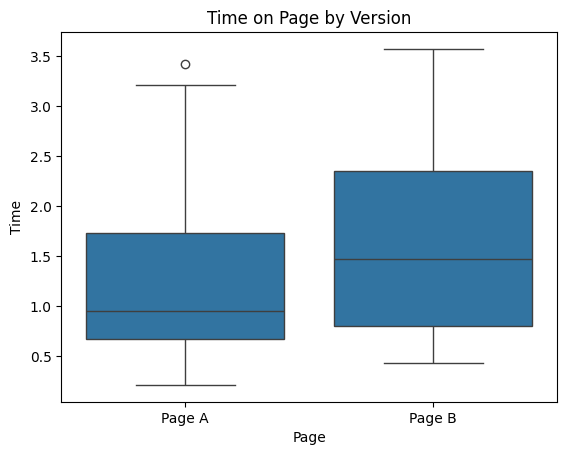

In [34]:
ax = sns.boxplot(x="Page", y="Time", data=web_sessions)
ax.set_title("Time on Page by Version")
plt.show()

# Parece muito que B tem um tempo médio maior que A, mas vamos testar isso com um teste de permutação.

Observed Difference: 0.3567
P-value: 0.1405


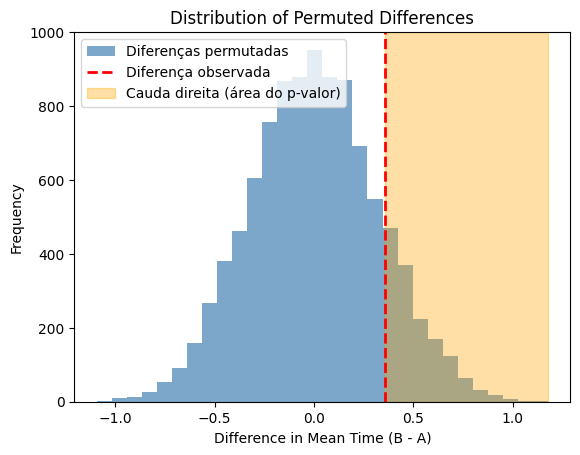

In [35]:
# permutation test
page_labels = web_sessions["Page"].astype(str).str.strip()
is_a = page_labels.str.fullmatch(r"Page A", case=False, na=False)
is_b = page_labels.str.fullmatch(r"Page B", case=False, na=False)

page_a = web_sessions.loc[is_a, "Time"]
page_b = web_sessions.loc[is_b, "Time"]

observed_diff = page_b.mean() - page_a.mean()  # diferença observada entre as médias

combined = np.concatenate([page_a, page_b])  # combina os dados das duas páginas
num_iter = 10000

permuted_diffs = np.empty(num_iter) # distribuição das diferenças permutadas
for i in range(num_iter):
    shuffled = np.random.permutation(combined)  # embaralha sem alterar o array original
    permuted_a = shuffled[:len(page_a)]  # nova amostra para a página A
    permuted_b = shuffled[len(page_a):]  # nova amostra para a página B
    permuted_diffs[i] = permuted_b.mean() - permuted_a.mean()  # diferença entre as médias dos grupos permutados


# aqui temos a probabilidade da diferença observada ser tão extrema quanto a que encontramos, assumindo que a hipótese nula é verdadeira (ou seja, que não há diferença real entre as páginas A e B).
p_value = np.mean(permuted_diffs >= observed_diff)  # p-valor para a hipótese alternativa de que B é maior que A
print(f"Observed Difference: {observed_diff:.4f}")
print(f"P-value: {p_value:.4f}")

# histograma das diferenças permutadas
plt.hist(permuted_diffs, bins=30, alpha=0.7, color='steelblue', label='Diferenças permutadas')
plt.axvline(observed_diff, color='red', linestyle='dashed', linewidth=2, label='Diferença observada')
plt.axvspan(observed_diff, permuted_diffs.max(), color='orange', alpha=0.35, label='Cauda direita (área do p-valor)')
plt.title('Distribution of Permuted Differences')
plt.xlabel('Difference in Mean Time (B - A)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### t-Tests and z-Tests

Antes do advento dos computadores testes de reamostragem (como o de permutacao) nao eram praticos pois ou nao tinha computadores ou eles nao eram fortes o suficiente. O Teste t surgiu como uma aproximação matemática muito precisa para esses testes manuais. É instantâneo e computacionalmente barato. Bibliotecas como scipy.stats (Python) ou o comando t.test (R) resolvem a matemática complexa para você. O importante é saber interpretar o output.

- Estatistica t: z-score usado no z-test representa quantos desvios padroes (populacionais) estamos da media, ou seja, precisamos da variancia populacional. A estatistica t é como se fosse um z-score mas usando variancia amostral e e penalizado pelo tamanho da amostra / graus de liberdade (quanto menor a amostra mais incerteza). Como a distribuicao t vira uma normal com n>30, nao precisamos usar o test-z pois o test-t serve tanto para amostras maiores ou menores que 30. Além disso, normalmente nao temos disponivel a variancia amostral e portanto o t-test é pau para toda obra (em casos especificos que podemos aproximar a distribuicao por exemplo binomial podemo fazer o z-test se quiser). A logica de t é a mesma...se é negativo esta abaixo da media e se é positivo esta acima da media.

- Distribuicao-t: usamos a distribuicao-t supondo que a hipotese nula é verdade para entao comparar o valor observado nessa distribuicao e fazer o teste. O valor-p nesse caso é a area da cauda dessa distribuicao-t que supoe a hipotese nula.


In [36]:
# teste de hipotese parametrico agora

t_stat, p_value_ttest = stats.ttest_ind(page_b, page_a, alternative='greater')
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value (t-test): {p_value_ttest:.4f}")

T-statistic: 1.1237
P-value (t-test): 0.1345


### Significancia estatistica e Valor-p

Significancia estatistica é como estatisticos medem se um experimento ou estudo teve um resultado mais incomum/extremo do que a pura sorte (acaso) pode gerar.

- Valor-p: É a probabilidade do modelo nulo (hipotese nula) obter resultados mais extremos/raros que os resultados observados. É a area (probabilidade acumulada) acima do valor (caudas) observado em casos unilaterais e 2x a area em casos bilaterais (podem ser pior ou melhor/maior ou menor) nas distribuicao da hipotese nula (assumindo que ela é verdade). Entao basicamente geramos uma (modelo nulo) distribuicao supondo que a hipotese é nula e vemos o quao raro seria o evento da hipotese alternativa (resultado observado) na hipotese nula. Se for muito raro (valor-p baixo) entao é significante mas se for muito comum (valor-p alto) entao o resultado pode ter sido só sorte.

<img src="imagens/valorp.png" width="600" style="display:block; margin:auto;">

- Alpha: É o limite/limiar de probabilidade que escolhemos para decidir oq é acaso e oq é evento raro. Se escolhermos um alpha de 5% ou 0.05, entao se nossa probabilidade acumulada do valor ser maior que o observado for menor que 5% entao temos um estatisticamente significante. Caso contrário, nao temos nada... 

- Controvérsia do valor-p: 

    A maior confusão é sobre o que ele realmente mede. A diferença é sutil: o p-valor foca na improbabilidade dos dados, não na veracidade da sua hipótese. (!!Nao estamos provando a hipotese nula!!)

    - ERRADO: "O p-valor de 0.03 significa que há apenas 3% de chance de o resultado ser coincidência (ou 97% de chance de eu estar certo)."  (Aqui estamos falando da populacao como se ela fosse o modelo nulo que assumimos)

    - CORRETO: "Assumindo que o mundo é puramente aleatório e minha ideia não funciona, a chance de eu ver esses dados específicos (ou algo mais extremo) é de 3%."  (Aqui assumimos que estamos com uma amostra e nossas probabilidade envolve amostragem... o valor-p serve para ver o quanto seus dados estao em desacordo com a hipotese nula)

- p-hacking: Se você testar 20 variáveis diferentes contra um resultado, estatisticamente uma delas provavelmente terá um p-valor < 0.05 apenas por puro azar. O pesquisador então publica apenas essa variável "vencedora" e ignora as outras 19 que falharam. Isso gera ciência de má qualidade e resultados que ninguém consegue replicar.

- Significancia Prática X Estatística: Conforme o tamanho da amostra cresce o erro padrao diminui e qualquer diferença minúscula (ex: um aumento de 0,0001% na taxa de cliques) se torna "estatisticamente significante" porque o teste tem poder suficiente para provar que aquele 0,0001% não foi sorte. Porém se o custo para os desenvolvedores alterarem o código, testarem e manterem essa mudança for de R$ 10.000, você precisaria de milhões de transações apenas para "empatar" o investimento. Um exemplo: o z-score em z-tests é medido pela diferenca observada / erro padrao, ou seja, a unidade de medida é erros padroes, se a amostra é grande o erro é minusculo e consequentemente nossa unidade também fica minuscula capiturando. Fica muito facil passar de 2 desvios padroes e consequentemente estar acima dos 95% centrais (significa que aceitamos um risco de 5% de cometer um Erro do Tipo I (concluir que existe um efeito quando, na verdade, é apenas ruído)) dos dados normais. Em um dataset com 10 milhões de usuários, uma diferença de apenas 0,001 na taxa de conversão pode gerar um Z=5,0. Um Z=5,0 está muito além dos 1,96 necessários para cobrir os 95%. Você está "fora do gráfico" da normalidade, mas a diferença real é quase invisível a olho nu. 

- Erros do tipo 1 e 2:

    - Tipo 1: Voce conclui que o efeito é real mas o efeito na verdade aconteceu por sorte.
    - Tipo 2: Voce conclui que o efeito foi sorte mas o efeito é na verdade real. (nesse caso pode ser por causa do tamanho da amostra entao talvez com uma amostra maior o efeito seja percebido)

    A funcao principal do teste de hipotese é nao ser enganado pela sorte uma vez que queremos minimizar o erro do tipo 1

- Para data science:

    Para um Data Scientist, o p-valor é uma medida de evidência, não uma prova. Ele ajuda a responder: "Vale a pena gastar meu tempo analisando isso?". Se o p-valor for alto, a resposta é não. Se for baixo, você olha para o ROI (Retorno sobre Investimento) para tomar a decisão final.

    - ROI (Retorn of investment ou Retorno de investimento): 

        - ROI = (Ganho do Investimento − Custo do Investimento) / Custo do Investimento
        - ROI (%) = [(Ganho − Custo) / Custo] × 100
        - ROI = (Valor Final − Valor Inicial) / Valor Inicial

    ROI é medido em unidades de "investimento inicial", quanto vou ganhar em termos de quanto investi.







Taxa de conversão A: 0.8425%  (200/23739)
Taxa de conversão B: 0.8057%  (182/22588)

Diferença observada (B - A): -0.000368

P-value (permutação): 0.6797


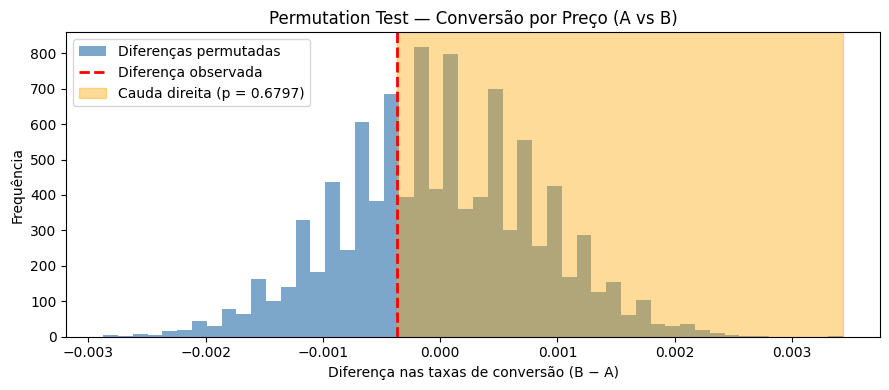


── Z-test para proporções (aproximação binomial) ──
Proporção pooled : 0.008246
Erro padrão (SE) : 0.000841
Z-score          : -0.4373
P-value (Z-test) : 0.6691

alpha = 0.05 → Falhamos em rejeitar H0 → diferença pode ser acaso.


In [37]:
conversions_a,  no_conv_a  = 200,  23_539   # preco A
conversions_b,  no_conv_b  = 182,  22_406   # preco B

group_a = np.array([1] * conversions_a  + [0] * no_conv_a,  dtype=np.float64)
group_b = np.array([1] * conversions_b  + [0] * no_conv_b,  dtype=np.float64)

n_a, n_b = len(group_a), len(group_b)
rate_a,  rate_b  = group_a.mean(), group_b.mean()

print(f"Taxa de conversão A: {rate_a:.4%}  ({conversions_a}/{n_a})")
print(f"Taxa de conversão B: {rate_b:.4%}  ({conversions_b}/{n_b})")

observed_diff_bin = rate_b - rate_a
print(f"\nDiferença observada (B - A): {observed_diff_bin:.6f}")

# ── Teste de Permutação ────────────────────────────────────────────────────────
combined_bin = np.concatenate([group_a, group_b])
num_iter_bin = 10_000

rng = np.random.default_rng(seed=42)
perm_diffs_bin = np.empty(num_iter_bin)

for i in range(num_iter_bin):
    shuffled = rng.permutation(combined_bin)
    perm_a = shuffled[:n_a]
    perm_b = shuffled[n_a:]
    perm_diffs_bin[i] = perm_b.mean() - perm_a.mean()

# teste unilateral: será que B > A?
p_value_perm = np.mean(perm_diffs_bin >= observed_diff_bin)
print(f"\nP-value (permutação): {p_value_perm:.4f}")


plt.figure(figsize=(9, 4))
plt.hist(perm_diffs_bin, bins=50, alpha=0.7, color='steelblue', label='Diferenças permutadas')
plt.axvline(observed_diff_bin, color='red', linestyle='dashed', linewidth=2, label='Diferença observada')
plt.axvspan(observed_diff_bin, perm_diffs_bin.max(), color='orange', alpha=0.4,
            label=f'Cauda direita (p = {p_value_perm:.4f})')
plt.title('Permutation Test — Conversão por Preço (A vs B)')
plt.xlabel('Diferença nas taxas de conversão (B − A)')
plt.ylabel('Frequência')
plt.legend()
plt.tight_layout()
plt.show()

# ── Aproximação pela Distribuição Binomial (Z-test para proporções) ────────────
# Sob H0: p_a = p_b = p_pooled → a diferença de proporções segue N(0, SE²)
# onde SE² vem da variância de Bernoulli: p*(1-p) * (1/n_a + 1/n_b)
from scipy.stats import norm

p_pooled_bin = (conversions_a + conversions_b) / (n_a + n_b)
se_bin = np.sqrt(p_pooled_bin * (1 - p_pooled_bin) * (1/n_a + 1/n_b))

z_score_bin = observed_diff_bin / se_bin
p_value_z   = 1 - norm.cdf(z_score_bin)   # unilateral (B > A)

print(f"\n── Z-test para proporções (aproximação binomial) ──")
print(f"Proporção pooled : {p_pooled_bin:.6f}")
print(f"Erro padrão (SE) : {se_bin:.6f}")
print(f"Z-score          : {z_score_bin:.4f}")
print(f"P-value (Z-test) : {p_value_z:.4f}")

alfa = 0.05
resultado = "Rejeitamos H0 → diferença estatisticamente significante!" if p_value_z < alfa \
            else "Falhamos em rejeitar H0 → diferença pode ser acaso."
print(f"\nalpha = {alfa} → {resultado}")


#### Problema de multiplos testes de hipotese nos mesmos dados

O lema "se voce torturar os dados suficiente, ele comeca a falar" entra aqui também... em um teste de hipotese que escolhemos alpha como 0.05 estamos falando que se a probabilidade de um evento tao raro quanto o observado supondo a hipotese nula (p-valor) é menor que 5% entao aceitamos a hipotese alternativa. Nesse caso estamos assumindo um risco de 5% de cometer o erro do tipo 1 que é concluir que existe efeito significativo mas na verdade existe apenas ruido. Entao a probabilidade de voce nao errar em um teste é 95%, com varios testes seguidos nos mesmos dados teremos 0.95 elevado ao numero de teste e esse produto vai diminuindo conforme voce faz mais testes... entao em algum momento a probabilidade de voce nao errar em algum momento vai chegar a proximo de zero.

Como mitigar isso ?

- Ajuste de Bonferroni: divide o α pelo número de testes n. Para 20 testes, seu novo "alvo" de p-valor seria 0,05/20=0,0025

- Para predicao use: cross validation e conjuntos de teste e validacao

- Para outras tarefas tome cuidado em tomar conclusoes depois de muitas hipoteses



#### Problema da Multicolinearidade e graus de liberdade

Quando transformamos uma variável categórica em colunas binárias (One-Hot Encoding), criamos redundância matemática se incluirmos todas as categorias. Imagine que você tem a variável "Dia da Semana". Você cria 7 colunas (Segunda a Domingo). Se o valor de uma linha é 0 para Segunda, Terça, Quarta, Quinta, Sexta e Sábado... obrigatoriamente o valor de Domingo será 1. Isso significa que a 7ª coluna é perfeitamente previsível a partir das outras 6.

- Pq é um problema?

Algoritmos de regressão (como a Regressão Linear ou Logística) tentam inverter matrizes para encontrar os coeficientes. Se uma coluna é uma combinação linear exata de outras, a matriz é "singular" e o algoritmo "engasga" (Multicollinearity Error). Entao, sempre descarte uma categoria (use k−1 colunas para k categorias). Se você tem 7 dias, use 6 colunas. A "falta" de marcação em todas as 6 colunas indica implicitamente a 7ª categoria (o chamado intercepto ou base).


### 

### Teste ANOVA

Suponha que ao inves de teste A/B temos um problema com varios grupos A/B/C/D e a variavel resultado/resposta de cada grupo é continua. ANOVA (Analysis of Variance) é o padrao para esse cenário uma vez que testa a hipotese nula de que as medias desses grupos sao iguais utilizando a distribuicao-F como referencia. Se você tem 3 grupos (A, B e C), você poderia pensar em fazer 3 Testes T (A vs B, B vs C, A vs C). No entanto, como vimos no problema de multiplos testes: Cada teste tem um risco de 5% de erro (α=0,05). Ao fazer 3 testes, seu risco total de erro sobe para cerca de 14%. O ANOVA resolve isso testando todos os grupos simultaneamente em um único "lance", mantendo o erro global em 5%.

Versao usando reamostragem:

1. Combine todos os dados em um conjunto
2. Shuffle e retire o mesmo numero de grupos e de mesmos tamanhos(sem reposicao e seguindo os tamanhos de cada um) 
3. grave a media dos 4 grupos
4. grave a variancia da media dos 4 grupos
5. Repita o os passos anteriores por I vezes sendo I o numero de iteracoes
6. Comparamos quantas vezes a variancia das reamostragem passou a variancia observada e podemos calcular nosso valor-p

- Teste Omnibus: O ANOVA é um teste omnibús, o que significa que ele te dá uma resposta geral. Se o resultado for significativo (p<0,05), ele apenas diz: "Pelo menos um desses grupos é diferente dos outros". Ele não diz qual deles.
Para descobrir especificamente qual par de grupos é diferente, você deve realizar um Teste Post-hoc, como o Tukey HSD.

- Two-way ANOVA: O que foi visto anteriormente é a one-way anova... A two-way é uma extensao dela que serve para analisar 2 fatores/metricas ao mesmo tempo. Usada quando você quer entender o efeito de dois fatores categóricos simultâneos sobre uma variável de resultado contínua. Em "poucas palavras", ela responde a três perguntas de uma vez:
    - Efeito do Fator A: O primeiro fator influencia o resultado?
    - Efeito do Fator B: O segundo fator influencia o resultado?
    - Interação (A × B): O efeito de um fator depende do nível do outro?

    Imagine que você quer testar o tempo de carregamento de um site (variável contínua): Fator 1 (Navegador): Chrome vs. Firefox e Fator 2 (Região): Brasil vs. EUA.
    A Two-way ANOVA diria se o tempo muda por causa do navegador, se muda por causa da região, ou se — por exemplo — o Chrome é rápido no Brasil mas lento nos EUA (isso seria uma interação).


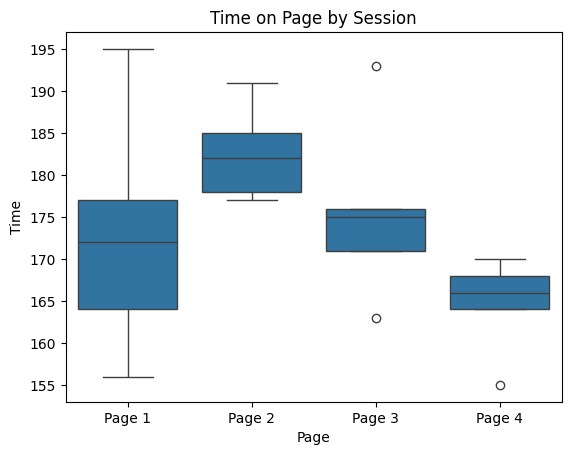

In [38]:
# ANOVA
four_sessions = pd.read_csv("data/four_sessions.csv")

sns.boxplot(x="Page", y="Time", data=four_sessions)
plt.title("Time on Page by Session")
plt.show()


In [39]:
# ANOVA usando reamostragem

variancia_observada = four_sessions.groupby("Page")["Time"].mean().var()
print(f"Variância observada entre as médias: {variancia_observada:.4f}")

num_iter_anova = 10000 # número de iterações para a permutação
permuted_variances = np.empty(num_iter_anova)
combined_anova = four_sessions["Time"].values # dados combinados para permutação
page_labels_anova = four_sessions["Page"].values # rótulos das páginas para permutação

for i in range(num_iter_anova):
    shuffled_labels = np.random.permutation(page_labels_anova) # embaralha os rótulos das páginas
    permuted_df = pd.DataFrame({"Page": shuffled_labels, "Time": combined_anova}) # cria um DataFrame com os rótulos embaralhados
    permuted_variances[i] = permuted_df.groupby("Page")["Time"].mean().var() # calcula a variância entre as médias para os dados permutados

p_value_anova = np.mean(permuted_variances >= variancia_observada)
print(f"P-value (ANOVA por permutação): {p_value_anova:.4f}")



Variância observada entre as médias: 55.4267
P-value (ANOVA por permutação): 0.0860


#### Estatistica F

Assim como o test-t pode ser usado no lugar do teste de permutacao para dois grupos (teste A/B). Existe o teste ANOVA baseado na distribuicao-F. Essa estatistica é definida como a Variancia entre os grupos devidida pela variancia dentro dos grupos. E portanto se F é baixo significa que a variacao entres os grupos é proxima a dentro dos grupos e portanto nao existe diferenca significativa entre eles... O valor da estatistica entao é comparado com uma distribuicao padrao F da hipotese nula em que estamos supondo que as medias de todos os grupos sao iguais.

In [40]:
# ANOVA usando teste F tradicional
from scipy.stats import f_oneway
groups = [group["Time"].values for name, group in four_sessions.groupby("Page")]
f_stat, p_value_f = f_oneway(*groups)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value (ANOVA F-test): {p_value_f:.4f}")

F-statistic: 2.7398
P-value (ANOVA F-test): 0.0776


### Teste qui-quadrado

O teste de qui-quadrado é usado com dados de contagem para comparar a distribuicao observada com a distribuicao esperada. O uso mais comum é para testar a independencia de duas variaveis categoricas usando uma tabela de contingencia.

Abordagem usando reamostragem:

1. junte todos os dados em conjunto (os dados de qualquer combinacao de classes das variaveis)
2. Shuffle e pegue N amostras de mesmo tamanho das classes das colunas sendo N o numero de colunas (classes)
3. Calcule a estatistica qui-quadrado e armazene
4. Repita o processo I vezes
5. Comparamos quantas vezes o qui-quadrado da reamostragem passou o qui-quadrado observado e podemos calcular nosso valor-p


- Quando usar: teste qui-quadrado é ideal quando estamos lidando com frequencias, contagens e categorias. Os casos mais comuns sao: 

    - Independencia: Você quer saber se a cor do botão (Azul vs. Vermelho) tem relação com a conversão (Comprou vs. Não Comprou).
    - Goodness of fit (comparar com distribuicao esperada): Você sabe que, na população brasileira, 52% são mulheres e 48% são homens. Se você coleta uma amostra para um app e tem 70% de homens, o teste Qui-quadrado de aderência vai te dizer se essa diferença é apenas sorte (ruído) ou se seu processo de coleta está enviesado.
    - Feature Selection: Se uma variável categórica (ex: "Cor Favorita do Usuário") é independente da sua variável alvo (ex: "Churn"), ela não tem poder preditivo. Você roda o teste e, se o p-valor for alto, você remove essa coluna do seu dataset para simplificar o modelo e evitar o overfitting.


In [41]:
# Teste Qui-quadrado para independência
df_qui = pd.DataFrame({
    "Headline A": [14, 986],
    "Headline B": [8, 992],
    "Headline C": [12, 988]
}, index=["Click", "No-click"])

observed_chi2 = stats.chi2_contingency(df_qui)[0]

# "pool" de dados reais (34 uns e 2966 zeros)
total_clicks = df_qui.loc["Click"].sum()
total_no_clicks = df_qui.loc["No-click"].sum()
all_outcomes = np.array([1] * total_clicks + [0] * total_no_clicks)

# (1000, 1000, 1000)
group_sizes = df_qui.sum().values 

num_iter_chi2 = 10000
permuted_chi2 = np.empty(num_iter_chi2)

for i in range(num_iter_chi2):

    np.random.shuffle(all_outcomes)
    
    # reconstrói a tabela com os mesmos tamanhos de grupo originais
    start = 0
    new_counts = []
    for size in group_sizes:
        group_slice = all_outcomes[start : start + size]
        clicks = group_slice.sum()
        no_clicks = size - clicks
        new_counts.append([clicks, no_clicks])
        start += size
    
    permuted_table = np.array(new_counts).T
    permuted_chi2[i] = stats.chi2_contingency(permuted_table)[0]

p_value_chi2_perm = np.mean(permuted_chi2 >= observed_chi2)

print(f"Chi-squared (Observado): {observed_chi2:.4f}")
print(f"P-value (Permutação): {p_value_chi2_perm:.4f}")



Chi-squared (Observado): 1.6659
P-value (Permutação): 0.4774


#### Estatistica Qui-Quadrado

Seguindo a mesma logica da t e da f, a chi^2 representa a estatistica usada para a forma parametrica do teste. O chi^2 representa a soma dos desvios em relacao a distribuicao esperada, dividido pela raiz do esperado. Depois calculamos a area da cauda da distribuicao padrao qui^2 sob hipotese nula em que os as variaveis sao independendes ou que os dados seguem a distribuicao esperada (Ser independente é equivalente a isso pois se sao independentes entao sabemos a distribuicao esperada que é a global). Depois pegamos o valor-p que é a probabilidade do erro do qui^2 ser maior do que o observado.


In [42]:
from scipy.stats import chi2_contingency
chi2_stat, p_value_chi2, dof, expected = chi2_contingency(df_qui)
print(f"Chi-squared statistic (Observado): {chi2_stat:.4f}")
print(f"P-value (Chi-squared test): {p_value_chi2:.4f}")

Chi-squared statistic (Observado): 1.6659
P-value (Chi-squared test): 0.4348


### Teste exato de Fisher

O teste qui-quadrado paramétrico nao é muito bom quando as contagens dos dados sao muito pequenas. Nesse caso é mais interessante usar o teste exato que testa todas as possibilidades de permutacao (As "permutações" no Fisher consistem em olhar para todas as formas de preencher os valores a,b,c,d de modo que os Totais (marginais) nunca mudem). Ela é cara mas é util pois os dados sao poucos. Se algumas contagens sao altas e outras baixas entao é necessário usar o teste usando reamostragem pois ele se aproxima melhor do exato.

In [43]:
# teste exato de Fisher nos mesmos dados
from scipy.stats import fisher_exact

result = fisher_exact(df_qui.values)
print(f"Odds Ratio: {result[0]:.4f}")
print(f"P-value (Fisher's Exact Test): {result[1]:.4f}")


Odds Ratio: 0.0105
P-value (Fisher's Exact Test): 0.4602


### For Data Science 

- Testes de significancia para tomada de decisao: Raramente paramos no "p-valor < 0,05". O objetivo em um teste A/B/C não é apenas dizer que as Headlines são diferentes, mas sim escolher a melhor. Em um teste de Qui-quadrado tradicional, você gasta tráfego enviando usuários para uma Headline ruim só para ter "certeza estatística" de que ela é ruim. Algoritmos de Bandits (como Thompson Sampling) são mais eficientes. Eles começam como um teste, mas conforme percebem que a "Headline A" está ganhando, passam a direcionar automaticamente mais tráfego para ela, maximizando a recompensa durante o próprio teste.

- Testes para Feature Selection: Esta é talvez a aplicação mais direta em pipelines de Machine Learning. Em vez de um "teste formal", o Qui-quadrado funciona como um filtro de ruído: Se você tem 500 variáveis categóricas, rodar um Qui-quadrado entre cada uma e o seu target ajuda a descartar o que é irrelevante. Estatística Espacial: Identificar se crimes ou falhas em servidores estão concentrados em uma área por "azar" ou por um padrão real (agrupamento).

- Tamanho da amostra: Se apenas 0,1% das pessoas clicam em um banner, mesmo com 10.000 visualizações, você terá apenas 10 cliques. Com números tão pequenos, o Qui-quadrado "quebra" (as aproximações falham). É aqui que o Teste Exato de Fisher brilha: ele ajuda a calcular se o seu teste tem "poder" (power) suficiente para chegar a uma conclusão ou se você precisa de mais 1 milhão de visualizações antes de decidir.


### Multi-arm bandit Algorithm

A formalizacao de experimentos e testes de hipotese sao meio inflexiveis e limitados no quesito de decisao. Se voce toma a decisao de um painel A ao invés de B com base em significancia apenas voce corre o risco de estar errado... nao usa informacoes a priori que voce tenha e também nao permite alteracoes durantes os testes... no ambiente empresarial isso pode levar a perda de dinheiro, ou melhor, custo de oportunidade. Nesse sentido vem os Bandit Algorithms, que permite testar varias possibilidades ao mesmo tempo (A/B/C...) e chegar a pequenas conclusoes locais (maximos locais) conforme o experimento acontece. Seu objetivo na empresa nao é provar uma hipotese e sim tomar decisoes que maximizem o lucro dela. Quanto mais cedo colocarmos o grupo que rende mais dinheiro para mais pessoas, mais dinheiro (ou métricas proxy como cliques) seria adquirido. 

Se temos 3 opcoes (A/B/C) e A comeca com certa vantagem sobre B e C... Podemos escolher A e pronto mas e se B e C forem melhores ? perdemos a oportunidade de descobrir isso... Outra decisao poderia ser vamos continuar colocando nossos recursos igualmente nas 3 opcoes mas dessa forma estariamos colocando 2/3 dos recursos em opcoes ruins e isso gera custo de oportunidade... bandit Algorithms sao uma solucao hibrida em que tentamos direcionar uma maior parcela dos recursos (usuários) na opcao que esta dominando atualmente, ou seja, queremos dar uma probabilidade maior para aquele que esta na frente pois assim nao perdemos maximizamos o lucro. Essa probabilidade a mais tem que ser coerente com a vantagem que a melhor opcao tem sobre as outras ou seja, se é só um pouco melhor colocamos só um pouco a mais de probabilidade... 

Um algoritmo simples de exemplo é o Epsylon Greedy aplicado para teste A/B:

1. Geramos um numero aleatório entre 0 e 1
2. Se o numero for menor que um valor epsylon, escolhemos entre A e B com probabilidade 50% para cada (Dando justica para todas as opcoes)
3. Se o numero for maior ou igual a epsylon, escolhemos o maximo local atual na métrica escolhida (cliques)
4. Ajuste epsylon de acordo com o quao melhor que os outros o atual melhor esta... Se muito melhor epsylon maior, senao, menor...

Existem algoritmos mais sofisticados como Thompson Sampling em que trabalhamos com uma distribuicao de probabilidade para cada opcao testada (A/B), essa distribuicao modela a probabilidade de um valor aleatório que vai de 0-1 e ela é alimentada pela informacao adquirida durante o experimento. Se um usuário clica quandoe estamos na opcao A, fazemos a distribuicao de A ir para direita para ele ter mais chances de um numero proximo de 1, caso o usuário nao clique levamos a distribuicao para esquerda que é mais proximo de 0. Quando formos decidir qual opcao usar com um usuário vamos amostrar um valor em todas as distribuicoes de 0-1 e vamos escolher o opcao que o valor for maior... Isso da mais chance para as opcoes que a distribuicao esta para direita (as melhores atuais opcoes) mas ainda permite que as outras tenham chance:

1. Incialmente nao temos informacoes sobre as opcoes entao a distribuicao de cada opcao comeca uniforme 
2. Sorteamoa um valor das distribuicoes e escolhemos a opcao que o valor é o maior
3. Colocamos para o usuário, se ele clicar modificamos a distribuicao dessa opcao para direita, caso contrário para esquerda
4. Novo usuário chega e voltamos ao passo 2


- Vantagens sobre testes tradicionais:

    - Não há "p-valor": Você não precisa esperar semanas para atingir significância estatística e tomar alguma decisao.

    - Redução do "Regret": Em um teste A/B, você perde dinheiro enviando 50% do tráfego para a opção pior até o fim do teste. No Thompson Sampling, o tráfego para a opção pior vai minguando organicamente.

    - Lida com 3+ grupos nativamente: Ele escala perfeitamente se você tiver 3, 10 ou 50 variações, ajustando as probabilidades de todas simultaneamente.

#### Experimento: Comparando Lucro Total entre as 3 Abordagens

Vamos simular um cenário real com **3 variantes de preço (A, B, C)** e **10.000 usuários** chegando sequencialmente. Cada conversão vale R$ 100.

**Configuração:**
- Taxas reais de conversão (desconhecidas pelos algoritmos): A=5%, B=8%, C=3%
- B é o melhor, mas ninguém sabe disso no início

**As 3 estratégias competem:**

| Estratégia | Mecanismo |
|---|---|
| **Teste A/B Clássico** | Divide igualmente os primeiros 3.000 usuários, roda teste de hipótese, joga tudo para o vencedor com os 7.000 restantes |
| **Epsilon-Greedy (ε=0.1)** | 10% do tempo explora aleatoriamente, 90% explora o melhor atual |
| **Thompson Sampling** | Amostra de distribuições Beta atualizadas por cada resultado — mais tráfego vai organicamente para o melhor |

Rodaremos **200 simulações Monte Carlo** para suavizar o ruído aleatório e comparar as médias.


Rodando simulações Monte Carlo…
  50/200 simulações concluídas
  100/200 simulações concluídas
  150/200 simulações concluídas
  200/200 simulações concluídas


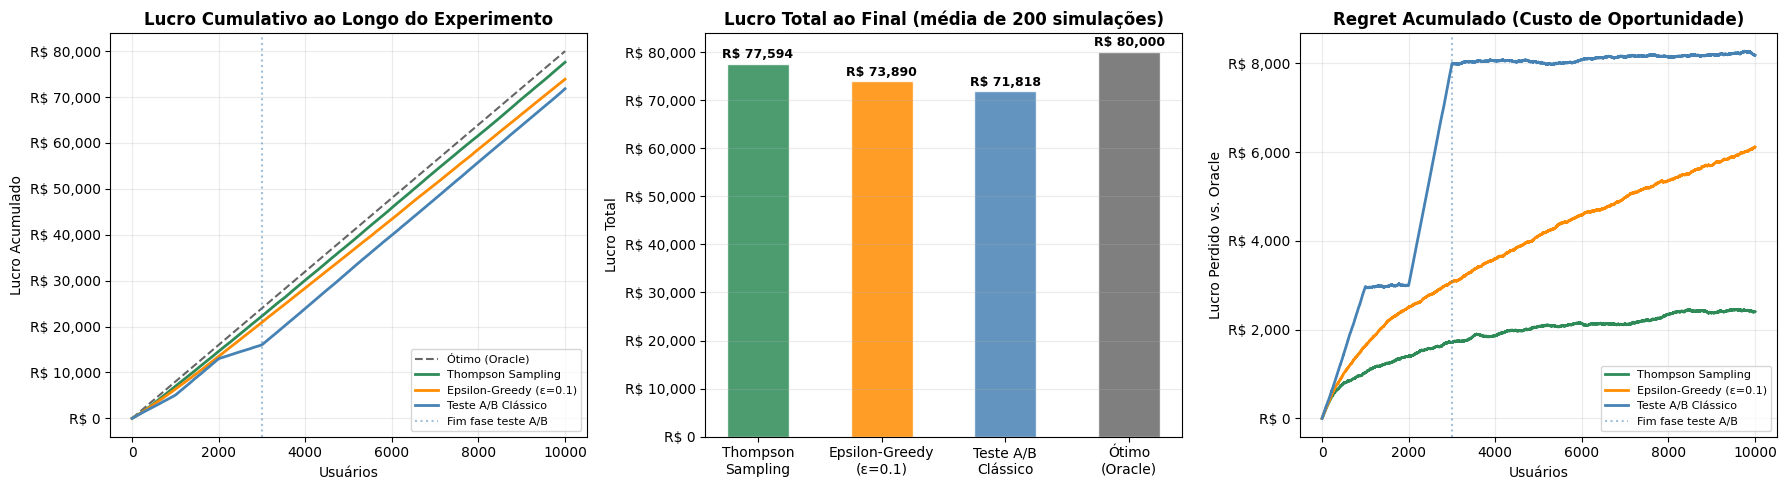


Estratégia                      Lucro Total    Regret Total
Thompson Sampling            R$      77,594  R$       2,406
Epsilon-Greedy (ε=0.1)       R$      73,890  R$       6,110
Teste A/B Clássico           R$      71,818  R$       8,182

 Taxas reais: A=5%  B=8%  C=3%  →  melhor: B
 Lucro ótimo (Oracle): R$ 80,000
 Simulações Monte Carlo: 200   |   Usuários por simulação: 10,000


In [44]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

np.random.seed(42)

TRUE_RATES      = {"A": 0.05, "B": 0.08, "C": 0.03}   # taxas reais (desconhecidas)
PROFIT_PER_CONV = 100          # R$ por conversão
N_USERS         = 10_000       # total de usuários
N_TEST_PHASE    = 3_000        # usuários gastos na fase de teste do A/B clássico
EPSILON         = 0.10         # exploração do Epsilon-Greedy
N_SIM           = 200          # simulações Monte Carlo p/ suavizar ruído
ARMS            = list(TRUE_RATES.keys()) # ["A", "B", "C"]

def pull(arm: str) -> int:
    return 1 if np.random.random() < TRUE_RATES[arm] else 0

# Estratégia 1: Teste A/B Clássico
def run_ab_test() -> np.ndarray:
    profit_curve = []
    total = 0
    counts = {a: {"s": 0, "n": 0} for a in ARMS}

    # tráfego dividido igualmente
    per_arm = N_TEST_PHASE // len(ARMS)
    for arm in ARMS:
        for _ in range(per_arm):
            r = pull(arm)
            counts[arm]["s"] += r
            counts[arm]["n"] += 1
            total += r * PROFIT_PER_CONV
            profit_curve.append(total)

    # decide o vencedor com z-test de proporções (two-sample, one-tail)
    winner = max(ARMS, key=lambda a: counts[a]["s"] / counts[a]["n"])

    # 100% do tráfego para o vencedor
    for _ in range(N_USERS - N_TEST_PHASE):
        r = pull(winner)
        total += r * PROFIT_PER_CONV
        profit_curve.append(total)

    return np.array(profit_curve)

# Estratégia 2: Epsilon-Greedy 
def run_epsilon_greedy() -> np.ndarray:
    profit_curve = []
    total = 0
    counts = {a: {"s": 0, "n": 0} for a in ARMS}

    for _ in range(N_USERS):
        if np.random.random() < EPSILON or any(counts[a]["n"] == 0 for a in ARMS):
            arm = np.random.choice(ARMS)          # exploração aleatória
        else:
            arm = max(ARMS, key=lambda a: counts[a]["s"] / counts[a]["n"])  # exploit

        r = pull(arm)
        counts[arm]["s"] += r
        counts[arm]["n"] += 1
        total += r * PROFIT_PER_CONV
        profit_curve.append(total)

    return np.array(profit_curve)

# Estratégia 3: Thompson Sampling
def run_thompson() -> np.ndarray:
    profit_curve = []
    total = 0
    alpha = {a: 1 for a in ARMS}   # prior Beta(1,1) = uniforme
    beta  = {a: 1 for a in ARMS}

    for _ in range(N_USERS):
        samples = {a: np.random.beta(alpha[a], beta[a]) for a in ARMS}
        arm = max(samples, key=samples.get)

        r = pull(arm)
        if r == 1:
            alpha[arm] += 1
        else:
            beta[arm] += 1

        total += r * PROFIT_PER_CONV
        profit_curve.append(total)

    return np.array(profit_curve)

# simulações Monte Carlo para suavizar o ruído e obter curvas médias de lucro acumulado
print("Rodando simulações Monte Carlo…")
ab_curves, eg_curves, ts_curves = [], [], []
for i in range(N_SIM):
    ab_curves.append(run_ab_test())
    eg_curves.append(run_epsilon_greedy())
    ts_curves.append(run_thompson())
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{N_SIM} simulações concluídas")

ab_mean = np.mean(ab_curves, axis=0)
eg_mean = np.mean(eg_curves, axis=0)
ts_mean = np.mean(ts_curves, axis=0)

# lucro ótimo caso soubéssemos desde o início quem é o melhor
optimal = np.arange(1, N_USERS + 1) * max(TRUE_RATES.values()) * PROFIT_PER_CONV

brl = mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# lucro acumulado ao longo do tempo
ax = axes[0]
users = np.arange(1, N_USERS + 1)
ax.plot(users, optimal,  "k--",              lw=1.5, label="Ótimo (Oracle)",        alpha=0.6)
ax.plot(users, ts_mean,  color="seagreen",   lw=2,   label="Thompson Sampling")
ax.plot(users, eg_mean,  color="darkorange",  lw=2,   label=f"Epsilon-Greedy (ε={EPSILON})")
ax.plot(users, ab_mean,  color="steelblue",  lw=2,   label="Teste A/B Clássico")
ax.axvline(N_TEST_PHASE, color="steelblue", ls=":", alpha=0.5, label="Fim fase teste A/B")
ax.set_title("Lucro Cumulativo ao Longo do Experimento", fontweight="bold")
ax.set_xlabel("Usuários")
ax.set_ylabel("Lucro Acumulado")
ax.yaxis.set_major_formatter(brl)
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

# lucro total final
ax2 = axes[1]
labels  = ["Thompson\nSampling", f"Epsilon-Greedy\n(ε={EPSILON})", "Teste A/B\nClássico", "Ótimo\n(Oracle)"]
values  = [ts_mean[-1], eg_mean[-1], ab_mean[-1], optimal[-1]]
colors2 = ["seagreen", "darkorange", "steelblue", "dimgray"]
bars = ax2.bar(labels, values, color=colors2, alpha=0.85, edgecolor="white", width=0.5)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 600,
             f"R$ {val:,.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax2.set_title("Lucro Total ao Final (média de 200 simulações)", fontweight="bold")
ax2.set_ylabel("Lucro Total")
ax2.yaxis.set_major_formatter(brl)
ax2.grid(axis="y", alpha=0.25)

# custo de oportunidade (regret acumulado)
ax3 = axes[2]
ax3.plot(users, optimal - ts_mean, color="seagreen",  lw=2, label="Thompson Sampling")
ax3.plot(users, optimal - eg_mean, color="darkorange", lw=2, label=f"Epsilon-Greedy (ε={EPSILON})")
ax3.plot(users, optimal - ab_mean, color="steelblue", lw=2, label="Teste A/B Clássico")
ax3.axvline(N_TEST_PHASE, color="steelblue", ls=":", alpha=0.5, label="Fim fase teste A/B")
ax3.set_title("Regret Acumulado (Custo de Oportunidade)", fontweight="bold")
ax3.set_xlabel("Usuários")
ax3.set_ylabel("Lucro Perdido vs. Oracle")
ax3.yaxis.set_major_formatter(brl)
ax3.legend(fontsize=8)
ax3.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("\n" + "=" * 65)
print(f"{'Estratégia':<28} {'Lucro Total':>14}  {'Regret Total':>14}")
print("=" * 65)
for name, val in [("Thompson Sampling",           ts_mean[-1]),
                  (f"Epsilon-Greedy (ε={EPSILON})", eg_mean[-1]),
                  ("Teste A/B Clássico",           ab_mean[-1])]:
    regret = optimal[-1] - val
    print(f"{name:<28} R$ {val:>11,.0f}  R$ {regret:>11,.0f}")
print("=" * 65)
print(f"\n Taxas reais: A={TRUE_RATES['A']:.0%}  B={TRUE_RATES['B']:.0%}  C={TRUE_RATES['C']:.0%}  →  melhor: B")
print(f" Lucro ótimo (Oracle): R$ {optimal[-1]:,.0f}")
print(f" Simulações Monte Carlo: {N_SIM}   |   Usuários por simulação: {N_USERS:,}")


### Power (poder estatistico)

Antes de gastar dinheiro coletando amostras é interessante saber se vale a pena... Power (Poder Estatístico) é a probabilidade de o seu teste detectar um efeito que realmente existe. Se o seu teste tem baixo poder, você pode estar diante de uma mina de ouro e concluir que é apenas terra, simplesmente porque não coletou amostras suficientes. 

Para calcular o tamanho da amostra (n), precisa equilibrar quatro variáveis:

- Tamanho da Amostra (n): O número de observações. É o que geralmente queremos descobrir.
- Effect Size (Tamanho do Efeito): É a "largura" da diferença que você quer detectar (ex: "quero ver se a conversão sobe de 5% para 7%").
- Significance Level (α): O risco de falso positivo que você aceita (geralmente 0,05).
- Power (1−β): A sensibilidade do teste. O padrão de mercado é 0,80 (80%), o que significa que, se o efeito existir, você tem 80% de chance de encontrá-lo.

Se voce tem qualquer um dos 3, consegue calcular o quarto elemento. Normalmente é usado para descobrir o tamanho da amostra... Imagine que voce tem uma pagina WEB e quer fazer um experimento sobre um novo painel B, se voce espera com esse novo painel que o numero de cliques aumente 50%, entao o effect size vai ser maior e consequentemente a quantidade de dados que voce precisa é menor pois é muito facil identificar essa diferenca grande de 50%. Se o effect size esperado é 5% entao a amostra terá que ser muito grande pois para indetificar uma variacao tao pequena é necessário muitos dados para ter certeza se nao é sorte ou azar. A signifancia é o risco que aceitamos no teste de hipotese e Power é a probabilidade de encontrar o efeito caso ele exista. Se você espera que sua nova funcionalidade mude drasticamente o comportamento do usuário (grande Effect Size), você precisa de poucos dados. Se a mudança for sutil (incremental), você precisará de milhões de acessos.

Abordagem de reamostragem:

1. Crie dois "baldes" virtuais:

    - Balde A: Com a taxa atual (ex: 1% de cliques).
    - Balde B: Com a taxa que você deseja detectar (ex: 1,1% de cliques).

2. Simule o teste:

    - Sorteie n amostras de cada balde (ex: n=1000).
    - Rode um teste de hipótese (como o Qui-quadrado ou Teste T).
    - Anote se o resultado foi "Significativo".

3. Repita 1000 vezes:

    - Se o resultado foi significativo em 800 das 1000 vezes, seu Poder é de 80% para aquele tamanho n.

- Ligacao com Multi-arm Bandit: Erro de rodar um teste A/B e pará-lo assim que o p-valor fica abaixo de 0,05 (Em testes usando A/B com algoritmos Bandit). Isso é perigoso! Sem um cálculo de Power prévio, você pode estar interrompendo o teste cedo demais (falso positivo por flutuação) ou tarde demais (gastando dinheiro à toa).


In [ ]:
# testando parametros do Power Analysis para encontrar tamanho de amostra
from statsmodels.stats.power import NormalIndPower


sample_size_small_effect = NormalIndPower().solve_power(effect_size=0.03, nobs1=None, alpha=0.05, power=0.8, ratio=1)
print(f"Tamanho de amostra necessário para detectar uma diferença de 3% com 80% de POWER: {sample_size_small_effect:.0f} usuários por grupo")
# "Se você quer saber se uma mudança visual mínima traz uma melhora sutil na conversão, prepare-se: você vai precisar de um tráfego gigante 
# (quase 35 mil pessoas no total) para ter 80% de chance de provar que esse ganho de 3% não foi apenas sorte."

sample_size_medium_effect = NormalIndPower().solve_power(effect_size=0.05, nobs1=None, alpha=0.05, power=0.8, ratio=1)
print(f"Tamanho de amostra necessário para detectar uma diferença de 5% com 80% de POWER: {sample_size_medium_effect:.0f} usuários por grupo")
# "Para um teste de mudança de 'copy' (texto) no site, o esforço é menor. Com cerca de 12.500 usuários divididos entre as duas versões, 
# você já consegue detectar se essa nova frase realmente performa 5% melhor que a antiga."

sample_size_large_effect = NormalIndPower().solve_power(effect_size=0.10, nobs1=None, alpha=0.05, power=0.8, ratio=1)
print(f"Tamanho de amostra necessário para detectar uma diferença de 10% com 80% de POWER: {sample_size_large_effect:.0f} usuários por grupo")
# "Como o efeito esperado é grande (10% de melhoria), você não precisa de muita gente. Com apenas 3.100 usuários totais, 
# você mata o teste rápido. Se o cupom for bom mesmo, a diferença vai 'subir' estatisticamente em pouco tempo."

effect_size = NormalIndPower().solve_power(effect_size=None, nobs1=3000, alpha=0.05, power=0.8, ratio=1)
print(f"Effect size mínimo detectável com 3000 usuários por grupo: {effect_size:.4f}")
# "Com o tráfego que temos hoje (3.000 por grupo), não adianta tentar medir melhorias minúsculas de 1% ou 2%. O nosso 'limite de visão' é de 7,2%. 
# Ou seja: qualquer mudança que melhore o site em menos de 7% provavelmente vai terminar com um resultado 'inconclusivo' (p-valor alto), 
# porque nossa amostra é pequena demais para enxergar detalhes."




Tamanho de amostra necessário para detectar uma diferença de 3% com 80% de POWER: 17442 usuários por grupo
Tamanho de amostra necessário para detectar uma diferença de 5% com 80% de POWER: 6279 usuários por grupo
Tamanho de amostra necessário para detectar uma diferença de 10% com 80% de POWER: 1570 usuários por grupo
Effect size mínimo detectável com 3000 usuários por grupo: 0.0723


O Erro padrao que representa a variabilidade da distribuicao das medias amostrais (TCL) reduz pela metade toda vez que quadruplicamos o tamanho da amostra... 

$$
SE(\bar{x}) = s / √n
$$

Quando estamos calculando um teste de hipotese estamos usando uma distribuicao padrao assumindo a hipotese nula em que os valores dela sao calculados seguindo uma formula como por exemplo do z-score...

$$
Z = \frac{\bar{X} - \mu_0}{s / \sqrt{n}}
$$

Repare que quanto maior o tamanho da amostra, menor é o erro padrao... consequentemente maior é o z-score. z-score significa numeros de desvios de distancia da media (se o desvio/erro é pequeno como no caso de amostras grandes, o numero de desvios aumenta). +-2 desvios padroes capturam aproximadamente 95% da distribuicao normal... Quando vamos calcular significancia de um teste usamos a distribuicao normal e calculamos a area da cauda que esta acima do resultado observado. Se esse valor normalizado (em z-score) estiver mais para o centro, vamos ter uma area maior do que nosso limite de significancia (alpha que é geralmente 0.05) e portanto vamos aceitar a hipotese nula. Porém quando aumentamos o valor de z indiretamente pelo tamanho da amostra nos estamos jogando nosso resultado observado para cauda da distribuicao e consequentemente reduzindo a area a direita (valor-p) e tornando o resultado significante.

--- Comparação Numérica ---
Cenário 1 (Não Significativo, N=100): Z = 1.0 | P-valor = 0.3173
Cenário 2 (Significativo, N=400): Z = 2.0 | P-valor = 0.0455


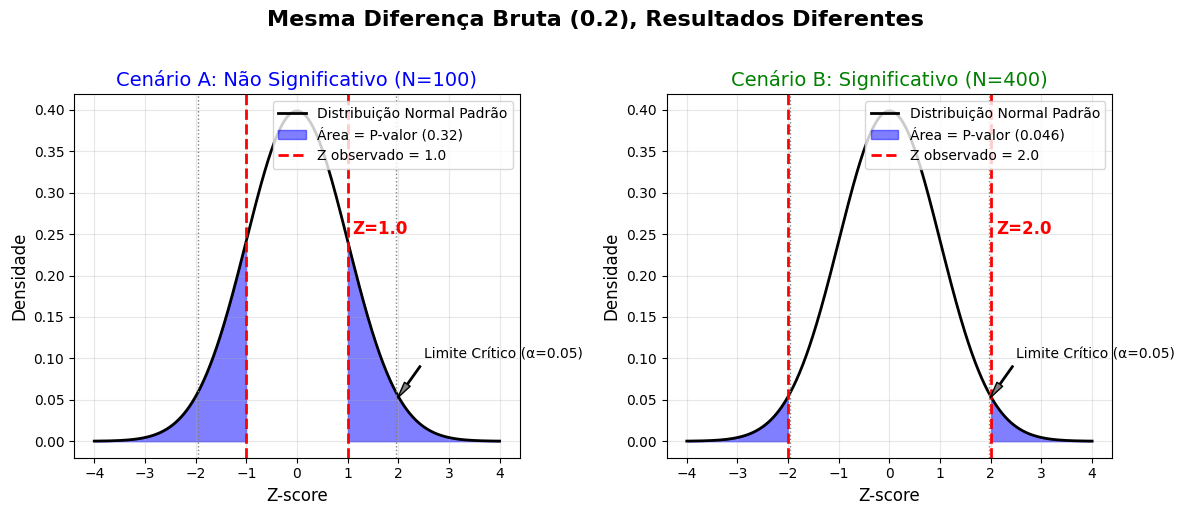

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

raw_difference = 0.2  # Diferença constante
sigma = 2.0           # Desvio padrão da população constante
alpha = 0.05          # Nível de significância constante

# Cenário 1: Não Significativo (Amostra Pequena)
n_small = 100
se_small = sigma / np.sqrt(n_small) # SE = 2 / 10 = 0.2
z_small = raw_difference / se_small # Z = 0.2 / 0.2 = 1.0
p_value_small = 2 * (1 - norm.cdf(np.abs(z_small)))

# Cenário 2: Significativo (Amostra Grande)
n_large = 400
se_large = sigma / np.sqrt(n_large) # SE = 2 / 20 = 0.1
z_large = raw_difference / se_large # Z = 0.2 / 0.1 = 2.0
p_value_large = 2 * (1 - norm.cdf(np.abs(z_large)))

plt.figure(figsize=(12, 5))
x = np.linspace(-4, 4, 1000)
y = norm.pdf(x)

plt.subplot(1, 2, 1)
plt.plot(x, y, color='black', linewidth=2, label='Distribuição Normal Padrão')
plt.fill_between(x, y, where=(x >= np.abs(z_small)), color='blue', alpha=0.5, label=f'Área = P-valor ({p_value_small:.2f})')
plt.fill_between(x, y, where=(x <= -np.abs(z_small)), color='blue', alpha=0.5)
plt.axvline(z_small, color='red', linestyle='--', linewidth=2, label=f'Z observado = {z_small:.1f}')
plt.axvline(-z_small, color='red', linestyle='--', linewidth=2)
plt.axvline(1.96, color='gray', linestyle=':', linewidth=1)
plt.axvline(-1.96, color='gray', linestyle=':', linewidth=1)
plt.text(z_small + 0.1, 0.25, f'Z={z_small:.1f}', color='red', fontsize=12, fontweight='bold')
plt.title(f'Cenário A: Não Significativo (N={n_small})', fontsize=14, color='blue')
plt.xlabel('Z-score', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.annotate('Limite Crítico (α=0.05)', xy=(1.96, 0.05), xytext=(2.5, 0.1), arrowprops=dict(facecolor='gray', shrink=0.05, width=1, headwidth=5))


plt.subplot(1, 2, 2)
plt.plot(x, y, color='black', linewidth=2, label='Distribuição Normal Padrão')
plt.fill_between(x, y, where=(x >= np.abs(z_large)), color='blue', alpha=0.5, label=f'Área = P-valor ({p_value_large:.3f})')
plt.fill_between(x, y, where=(x <= -np.abs(z_large)), color='blue', alpha=0.5)
plt.axvline(z_large, color='red', linestyle='--', linewidth=2, label=f'Z observado = {z_large:.1f}')
plt.axvline(-z_large, color='red', linestyle='--', linewidth=2)
plt.axvline(1.96, color='gray', linestyle=':', linewidth=1)
plt.axvline(-1.96, color='gray', linestyle=':', linewidth=1)
plt.text(z_large + 0.1, 0.25, f'Z={z_large:.1f}', color='red', fontsize=12, fontweight='bold')
plt.title(f'Cenário B: Significativo (N={n_large})', fontsize=14, color='green')
plt.xlabel('Z-score', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.annotate('Limite Crítico (α=0.05)', xy=(1.96, 0.05), xytext=(2.5, 0.1), arrowprops=dict(facecolor='gray', shrink=0.05, width=1, headwidth=5))

plt.suptitle('Mesma Diferença Bruta (0.2), Resultados Diferentes', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()


print(f"--- Comparação Numérica ---")
print(f"Cenário 1 (Não Significativo, N={n_small}): Z = {z_small:.1f} | P-valor = {p_value_small:.4f}")
print(f"Cenário 2 (Significativo, N={n_large}): Z = {z_large:.1f} | P-valor = {p_value_large:.4f}")

plt.show()

## Simulações de Monte Carlo

Simulações de Monte Carlo são uma técnica computacional que usa **aleatoriedade repetida em larga escala** para resolver problemas que seriam analiticamente difíceis ou impossíveis. O nome é em homenagem ao Cassino de Monte Carlo, em Mônaco, por causa da natureza aleatória dos jogos de azar. Foram desenvolvidas por Stanislaw Ulam e John von Neumann durante o Projeto Manhattan na década de 1940.

A ideia central é simples: **se você não consegue calcular a resposta exata de um problema, simule o processo aleatório que o gera milhares de vezes e use a média dos resultados como sua estimativa.**

### Como funciona?

O algoritmo geral é sempre o mesmo, independentemente do problema:

1. **Defina o modelo**: Identifique as variáveis aleatórias do problema e suas distribuições (ex: taxa de conversão segue Bernoulli, retorno de ação segue Normal, tempo de vida segue Exponencial).
2. **Sorteie**: Gere amostras aleatórias das distribuições definidas — um "cenário possível do mundo".
3. **Calcule**: Para cada cenário sorteado, compute a métrica de interesse (lucro, VaR, probabilidade, área, etc.).
4. **Repita** N vezes (quanto maior N, mais preciso — tipicamente 1.000 a 100.000 iterações).
5. **Agregue**: A distribuição dos N resultados é sua resposta. Use a média, percentis ou a proporção de cenários acima/abaixo de um limiar.

### Por que funciona? — Lei dos Grandes Números

Pela **Lei dos Grandes Números**, a média de N amostras independentes converge para o valor esperado real conforme N → ∞. Assim, ao repetir a simulação muitas vezes, a média dos resultados se aproxima da resposta verdadeira mesmo sem uma fórmula fechada.

$$\bar{X}_N = \frac{1}{N} \sum_{i=1}^{N} X_i \xrightarrow{N \to \infty} \mathbb{E}[X] = Media Populacional$$

### Erro da estimativa

O erro padrão de uma estimativa Monte Carlo decai com a raiz do número de simulações:

$$\text{SE} = \frac{\sigma}{\sqrt{N}}$$

Para reduzir o erro à metade, você precisa de **4× mais simulações**. Isso é o principal custo: precisão exige iterações.

### Monte Carlo vs. Fórmulas analíticas

| | Monte Carlo | Fórmula Analítica |
|---|---|---|
| **Quando usar** | Problema complexo, muitas variáveis, sem fórmula fechada | Problema simples com solução matemática conhecida |
| **Precisão** | Aproximado (melhora com N) | Exato |
| **Custo** | Computacional (CPU/tempo) | Memória e derivação matemática |
| **Flexibilidade** | Alta — qualquer distribuição, qualquer dependência | Baixa — exige simplificações |



π estimado com 100,000 dardos: 3.147360  (real: 3.141593)

Portfólio: R$ 100,000  |  μ=0.05%/dia  |  σ=1.20%/dia
VaR 95%: Você perde mais de R$ 1,926 em apenas 5% dos dias
VaR 99%: Você perde mais de R$ 2,738 em apenas 1% dos dias


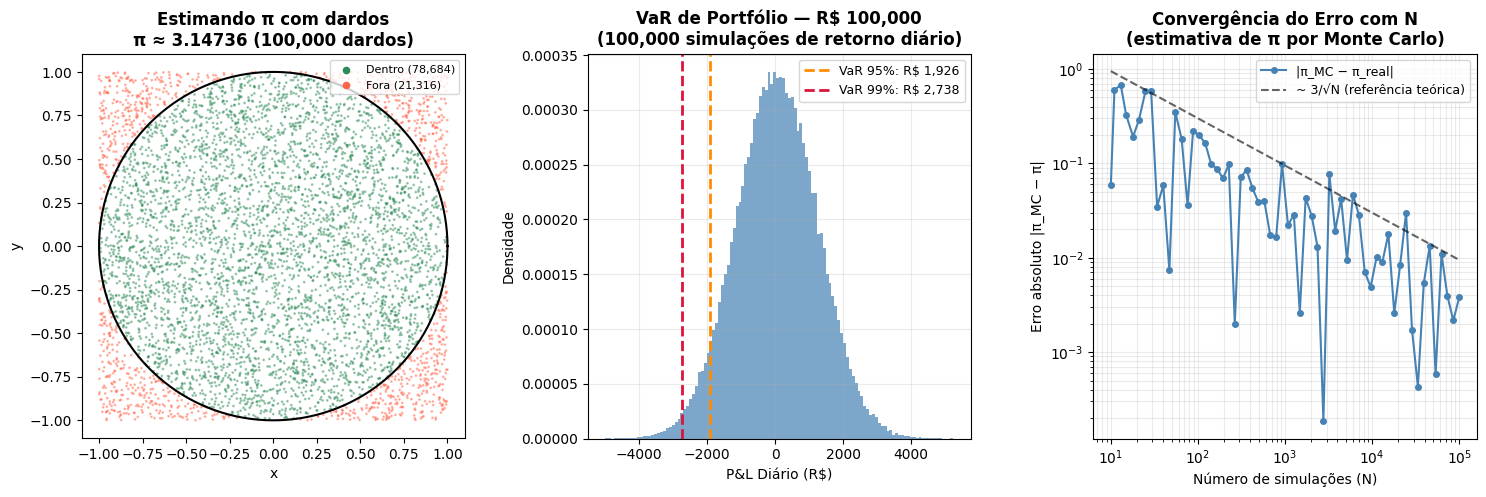


Conclusão: o erro cai proporcionalmente a 1/√N.
  N=100   → erro ≈ 0.1982
  N=1.000 → erro ≈ 0.0221  (√10 × menor)
  N=10.000→ erro ≈ 0.0101  (√100 × menor)


In [57]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

rng = np.random.default_rng(0)

# ══════════════════════════════════════════════════════════════════════════════
# Exemplo 1 — Estimar π jogando dardos aleatórios num quadrado unitário
# ══════════════════════════════════════════════════════════════════════════════
# Ideia: Um círculo de raio 1 inscrito num quadrado 2×2 tem área π.
# A razão (pontos dentro do círculo) / (total de pontos) ≈ π/4.

N_darts = 100_000
x_dart = rng.uniform(-1, 1, N_darts)
y_dart = rng.uniform(-1, 1, N_darts)
inside = (x_dart**2 + y_dart**2) <= 1.0

pi_estimates = 4 * np.cumsum(inside) / np.arange(1, N_darts + 1)  # estimativa acumulada

print(f"π estimado com {N_darts:,} dardos: {pi_estimates[-1]:.6f}  (real: {np.pi:.6f})")

# ══════════════════════════════════════════════════════════════════════════════
# Exemplo 2 — VaR de um portfólio de ações (Value at Risk)
# ══════════════════════════════════════════════════════════════════════════════
# Você tem R$ 100.000 investidos. Retorno diário ~ Normal(μ=0.05%, σ=1.2%).
# Qual é o VaR a 95%? (ou seja: qual perda máxima em 95% dos dias?)

capital      = 100_000
mu_ret       = 0.0005   # retorno médio diário
sigma_ret    = 0.012    # volatilidade diária
N_portfolio  = 100_000

daily_returns = rng.normal(mu_ret, sigma_ret, N_portfolio)
daily_pnl     = capital * daily_returns  # lucro/perda em R$

VaR_95 = np.percentile(daily_pnl, 5)    # 5º percentil = limite inferior de 95% dos dias
VaR_99 = np.percentile(daily_pnl, 1)

print(f"\nPortfólio: R$ {capital:,}  |  μ={mu_ret:.2%}/dia  |  σ={sigma_ret:.2%}/dia")
print(f"VaR 95%: Você perde mais de R$ {-VaR_95:,.0f} em apenas 5% dos dias")
print(f"VaR 99%: Você perde mais de R$ {-VaR_99:,.0f} em apenas 1% dos dias")

# ══════════════════════════════════════════════════════════════════════════════
# Exemplo 3 — Convergência: como o erro cai com √N
# ══════════════════════════════════════════════════════════════════════════════
sample_sizes  = np.logspace(1, 5, 60).astype(int)
pi_per_size   = []
for n in sample_sizes:
    xs = rng.uniform(-1, 1, n)
    ys = rng.uniform(-1, 1, n)
    pi_per_size.append(4 * np.mean(xs**2 + ys**2 <= 1))

errors = np.abs(np.array(pi_per_size) - np.pi)
theoretical_se = 1 / np.sqrt(sample_sizes)    # erro teórico ∝ 1/√N

# ══════════════════════════════════════════════════════════════════════════════
# Visualização — 3 painéis
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.32)

# Dardos 
ax1 = fig.add_subplot(gs[0])
n_show = 6_000
colors_dart = np.where(inside[:n_show], "seagreen", "tomato")
ax1.scatter(x_dart[:n_show], y_dart[:n_show], c=colors_dart, s=1, alpha=0.4, rasterized=True)
theta = np.linspace(0, 2 * np.pi, 300)
ax1.plot(np.cos(theta), np.sin(theta), "k-", lw=1.5)
ax1.set_aspect("equal")
ax1.set_title(f"Estimando π com dardos\nπ ≈ {pi_estimates[-1]:.5f} ({N_darts:,} dardos)", fontweight="bold")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.legend(
    handles=[
        plt.scatter([], [], c="seagreen", s=20, label=f"Dentro ({inside.sum():,})"),
        plt.scatter([], [], c="tomato",   s=20, label=f"Fora ({(~inside).sum():,})")
    ], fontsize=8, loc="upper right"
)

# Distribuição do P&L diário com VaR
ax2 = fig.add_subplot(gs[1])
ax2.hist(daily_pnl, bins=120, color="steelblue", alpha=0.7, edgecolor="none", density=True)
ax2.axvline(VaR_95, color="darkorange", lw=2, ls="--", label=f"VaR 95%: R$ {-VaR_95:,.0f}")
ax2.axvline(VaR_99, color="crimson",    lw=2, ls="--", label=f"VaR 99%: R$ {-VaR_99:,.0f}")
ax2.set_title(f"VaR de Portfólio — R$ {capital:,}\n({N_portfolio:,} simulações de retorno diário)", fontweight="bold")
ax2.set_xlabel("P&L Diário (R$)")
ax2.set_ylabel("Densidade")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.25)

# Convergência do erro com o número de simulações
ax3 = fig.add_subplot(gs[2])
ax3.loglog(sample_sizes, errors, "o-", color="steelblue", ms=4, lw=1.5, label="|π_MC − π_real|")
ax3.loglog(sample_sizes, theoretical_se * 3, "k--", lw=1.5, alpha=0.6, label="~ 3/√N (referência teórica)")
ax3.set_title("Convergência do Erro com N\n(estimativa de π por Monte Carlo)", fontweight="bold")
ax3.set_xlabel("Número de simulações (N)")
ax3.set_ylabel("Erro absoluto |π_MC − π|")
ax3.legend(fontsize=9)
ax3.grid(alpha=0.25, which="both")

plt.show()

print("\nConclusão: o erro cai proporcionalmente a 1/√N.")
print(f"  N=100   → erro ≈ {errors[np.searchsorted(sample_sizes, 100)]:.4f}")
print(f"  N=1.000 → erro ≈ {errors[np.searchsorted(sample_sizes, 1000)]:.4f}  (√10 × menor)")
print(f"  N=10.000→ erro ≈ {errors[np.searchsorted(sample_sizes, 10000)]:.4f}  (√100 × menor)")
